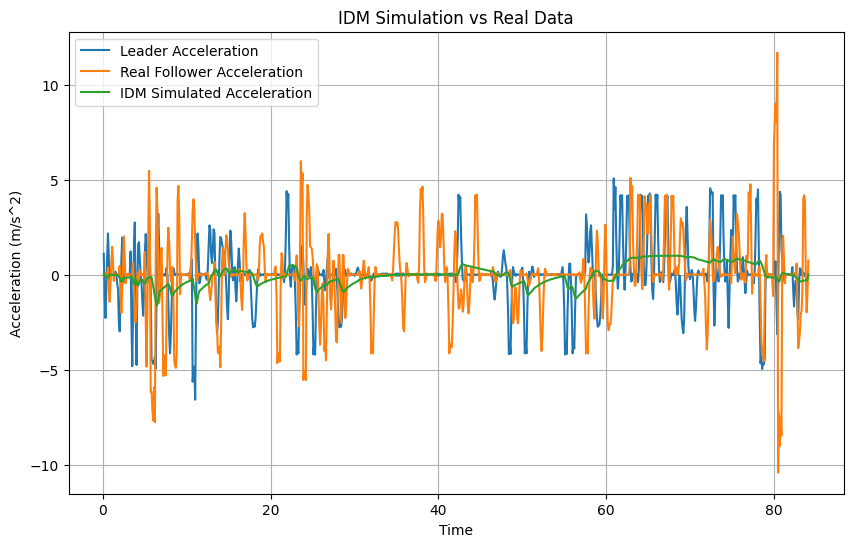

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("NGSIM.csv")

# Select a trajectory
traj_id = df["trajectory_number"].iloc[0]
traj_df = df[df["trajectory_number"] == traj_id].copy()
traj_df = traj_df.sort_values("Time").reset_index(drop=True)

# Extract data
time = traj_df["Time"].values
leader_position = traj_df["leader_position(m)"].values
leader_speed = traj_df["leader_speed(m/s)"].values
leader_acc = traj_df["leader_acc(m/s^2)"].values

follower_position = traj_df["follower_position(m)"].values
follower_speed = traj_df["follower_speed(m/s)"].values
follower_acc = traj_df["follower_acc(m/s^2)"].values

dt = time[1] - time[0]
n_steps = len(time)

# IDM function
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    s = max(s, 1e-6)
    s_star = s0 + v*T + (v*delta_v)/(2*np.sqrt(a*b))
    s_star = max(s_star, s0)
    return a * (1 - (v/v0)**delta - (s_star/s)**2)

# Parameters
v0 = 30
s0 = 2
T = 1.5
a_param = 1.0
b = 1.5
delta = 4

# Initialize simulation arrays
sim_position = np.zeros(n_steps)
sim_speed = np.zeros(n_steps)
sim_acc = np.zeros(n_steps)

sim_position[0] = follower_position[0]
sim_speed[0] = follower_speed[0]

# Simulation loop
for i in range(n_steps - 1):
    s = leader_position[i] - sim_position[i]
    delta_v = sim_speed[i] - leader_speed[i]

    acc = idm_acceleration(sim_speed[i], s, delta_v, v0, s0, T, a_param, b, delta)
    sim_acc[i] = acc

    sim_speed[i+1] = sim_speed[i] + acc * dt
    sim_position[i+1] = sim_position[i] + sim_speed[i] * dt

# Plot acceleration comparison
plt.figure(figsize=(10, 6))

plt.plot(time, leader_acc, label="Leader Acceleration")
plt.plot(time, follower_acc, label="Real Follower Acceleration")
plt.plot(time, sim_acc, label="IDM Simulated Acceleration")

plt.xlabel("Time")
plt.ylabel("Acceleration (m/s^2)")
plt.title("IDM Simulation vs Real Data")
plt.legend()
plt.grid(True)

plt.show()